# 04 - Optimisation du seuil métier et des hyperparamètres

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix
import warnings
import re
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)  # masque les logs verbeux
warnings.filterwarnings('ignore')

## 1. Chargement des données

In [2]:
df = pd.read_csv('../data/processed/dataset_final.csv')
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Nettoyage des noms de colonnes (requis par LightGBM)
X.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Réentraînement LightGBM sur le train complet
model = LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, verbosity=-1)
model.fit(X_train, y_train)

# Probabilités de défaut sur le test
y_prob = model.predict_proba(X_test)[:, 1]

print('Modèle entraîné')
print(f'AUC test : {roc_auc_score(y_test, y_prob):.4f}')

Modèle entraîné
AUC test : 0.7719


**Analyse :** Le chargement crée deux sets identiques en distribution (8.07% de défauts grâce à `stratify=y`). Le modèle de base (n_estimators=100, paramètres par défaut) sert de référence avant tuning — AUC 0.7719.

## 2. Optimisation des hyperparamètres avec Optuna

GridSearchCV teste toutes les combinaisons. **Optuna** utilise un algorithme bayésien — il apprend des essais précédents pour orienter la recherche vers les zones prometteuses.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    """Fonction que Optuna va maximiser — retourne l'AUC moyenne en CV."""
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 300),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'class_weight'    : 'balanced',
        'random_state'    : 42,
        'n_jobs'          : -1,
        'verbosity'       : -1,
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    return scores.mean()

# Lancement de l'optimisation
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nMeilleur AUC CV : {study.best_value:.4f}')
print(f'Meilleurs paramètres : {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


Meilleur AUC CV : 0.7686
Meilleurs paramètres : {'n_estimators': 237, 'max_depth': 3, 'learning_rate': 0.19341661535922583, 'num_leaves': 85, 'min_child_samples': 75}


**Analyse :** Meilleur AUC CV : 0.7686 avec n_estimators=237, max_depth=3, learning_rate=0.193, num_leaves=85, min_child_samples=75. Des feuilles plus nombreuses (85 vs 32 avant) mais des arbres moins profonds (max_depth=3) — Optuna favorise la largeur plutôt que la profondeur sur ce dataset réduit à 120 features.

## 3. Entraînement du modèle final

On entraîne LightGBM avec les meilleurs hyperparamètres trouvés par Optuna.

In [4]:
best_params = study.best_params
best_params.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbosity': -1})

model_final = LGBMClassifier(**best_params)
model_final.fit(X_train, y_train)

y_prob = model_final.predict_proba(X_test)[:, 1]

print(f'AUC test (modèle tuné) : {roc_auc_score(y_test, y_prob):.4f}')

AUC test (modèle tuné) : 0.7738


**Analyse :** AUC test 0.7738 — amélioration vs base (+0.0019). Le gain est modeste car LightGBM avec ses paramètres par défaut est déjà bien calibré sur ce type de données.

## 4. Optimisation du seuil métier

Maintenant qu'on a le meilleur modèle, on cherche le seuil qui minimise le coût métier : **FN coûte 10x plus qu'un FP**.

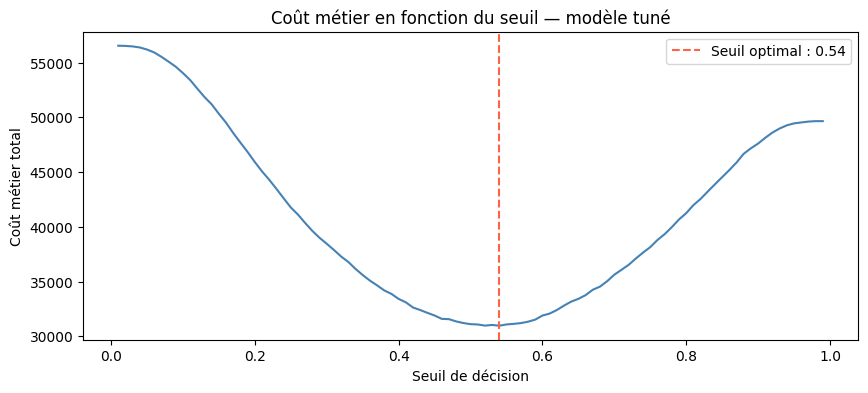

Seuil 0.50 → Sensibilité : 0.6916 | Spécificité : 0.7205 | Coût : 31113
Seuil 0.54 → Sensibilité : 0.6415 | Spécificité : 0.7671 | Coût : 30970


In [5]:
COUT_FN = 10
COUT_FP = 1

seuils = np.arange(0.01, 1.0, 0.01)
couts = []

for seuil in seuils:
    y_pred = (y_prob >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    couts.append(fn * COUT_FN + fp * COUT_FP)

seuil_optimal = seuils[np.argmin(couts)]

plt.figure(figsize=(10, 4))
plt.plot(seuils, couts, color='steelblue')
plt.axvline(seuil_optimal, color='tomato', linestyle='--', label=f'Seuil optimal : {seuil_optimal:.2f}')
plt.xlabel('Seuil de décision')
plt.ylabel('Coût métier total')
plt.title('Coût métier en fonction du seuil — modèle tuné')
plt.legend()
plt.show()

# Comparaison 0.5 vs seuil optimal
for seuil in [0.5, seuil_optimal]:
    y_pred = (y_prob >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    cout = fn * COUT_FN + fp * COUT_FP
    print(f'Seuil {seuil:.2f} → Sensibilité : {sens:.4f} | Spécificité : {spec:.4f} | Coût : {cout}')

## 5. Logging MLflow — modèle final

On log dans MLflow les meilleurs hyperparamètres, le seuil optimal, les métriques finales et le modèle lui-même dans le **Model Registry**.

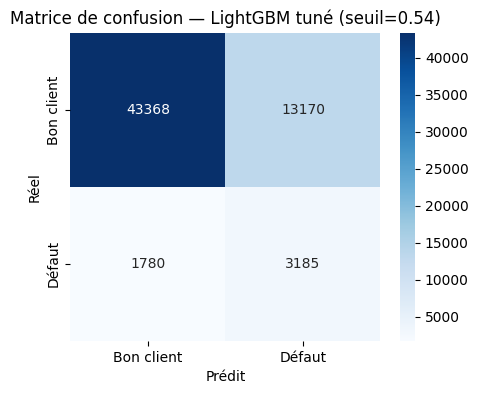

2026/03/30 13:21:18 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AUC test    : 0.7738
Sensibilité : 0.6415
Spécificité : 0.7671
Coût métier : 30970
Seuil       : 0.54

Modèle loggé dans le Model Registry : scoring-credit-lgbm


Successfully registered model 'scoring-credit-lgbm'.
Created version '1' of model 'scoring-credit-lgbm'.


In [10]:
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('scoring-credit')

# Calcul des métriques finales avec le seuil optimal
y_pred_final = (y_prob >= seuil_optimal).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
auc_final      = roc_auc_score(y_test, y_prob)
sensibilite    = tp / (tp + fn)
specificite    = tn / (tn + fp)
cout_final     = fn * COUT_FN + fp * COUT_FP

with mlflow.start_run(run_name='lightgbm_optuna_final'):

    # Hyperparamètres Optuna
    for param, value in study.best_params.items():
        mlflow.log_param(param, value)
    mlflow.log_param('seuil_optimal', seuil_optimal)

    # Métriques test (mêmes noms que 03_training_mlflow)
    mlflow.log_metric('auc_cv',     study.best_value)
    mlflow.log_metric('auc_test',    auc_final)
    mlflow.log_metric('sensibilite_test', sensibilite)
    mlflow.log_metric('specificite_test', specificite)
    mlflow.log_metric('cout_metier', cout_final)

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bon client', 'Défaut'],
                yticklabels=['Bon client', 'Défaut'])
    ax.set_xlabel('Prédit') ; ax.set_ylabel('Réel')
    ax.set_title(f'Matrice de confusion — LightGBM tuné (seuil={seuil_optimal:.2f})')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()

    # Sauvegarde dans le Model Registry
    mlflow.lightgbm.log_model(model_final, name='model', registered_model_name='scoring-credit-lgbm')

    print(f'AUC test    : {auc_final:.4f}')
    print(f'Sensibilité : {sensibilite:.4f}')
    print(f'Spécificité : {specificite:.4f}')
    print(f'Coût métier : {cout_final}')
    print(f'Seuil       : {seuil_optimal:.2f}')
    print('\nModèle loggé dans le Model Registry : scoring-credit-lgbm')

**Analyse :**

- **Optuna** améliore légèrement l'AUC : 0.7738 vs 0.7719 base (+0.0019).
- **Seuil optimal = 0.54** — légèrement au-dessus de 0.5, le modèle est un peu conservateur. En montant le seuil on accepte moins de défauts → sensibilité baisse (0.692 → 0.642) mais spécificité monte (0.721 → 0.767).
- **Coût métier** passe de 31 113 (seuil 0.50) à 30 970 (seuil 0.54) — gain de 143, le seuil 0.54 est marginalement meilleur selon la fonction de coût FN=10×FP.
- Modèle loggé dans le Model Registry et prêt pour le serving.

In [11]:
from mlflow.tracking import MlflowClient
client = MlflowClient(tracking_uri='../mlruns')
for mv in client.search_model_versions("name='scoring-credit-lgbm'"):
    print(mv.version, mv.run_id, mv.source)

1 d855d4cd0fc34f79b0f7a91ad73c4542 models:/m-b107b7a029224830823545baca985158


**Analyse :** On récupère son `run_id` pour construire l'URI de serving.

## 6. MLflow Serving

Une fois le modèle enregistré dans le Model Registry, MLflow permet de l'exposer comme une **API REST** en une seule commande. N'importe quelle application peut alors envoyer des données et recevoir une prédiction — sans avoir besoin du code Python du modèle.

### 6.1 Lancer le serveur

Commande à exécuter dans un terminal (venv activé, depuis la racine du projet) :

```bash
mlflow models serve \
  -m "runs:/d855d4cd0fc34f79b0f7a91ad73c4542/model" \
  --port 5001 \
  --no-conda
```

Le serveur écoute sur `http://127.0.0.1:5001`. L'endpoint de prédiction est `/invocations`.

### 6.2 Préparer la requête

Le format attendu par MLflow est `dataframe_split` : un dictionnaire avec les noms de colonnes et les valeurs. On prend un client du test set comme exemple.

In [12]:
import json

# On prend la première ligne du test set comme exemple
sample = X_test.iloc[[0]]

payload = {
    "dataframe_split": {
        "columns": sample.columns.tolist(),
        "data": sample.values.tolist()
    }
}

### 6.3 Envoyer la requête et interpréter la réponse

In [10]:
import requests

response = requests.post(
    'http://127.0.0.1:5001/invocations',
    headers={'Content-Type': 'application/json'},
    data=json.dumps(payload)
)

print('Status :', response.status_code)
print('Réponse :', response.json())

Status : 200
Réponse : {'predictions': [0]}


**Analyse :** Status 200 — la requête a réussi. Le modèle renvoie `0` (bon client) pour ce client. Le serving MLflow expose le modèle exactement comme il ferait une prédiction locale, mais via HTTP — ce qui permet de l'intégrer dans n'importe quelle application.